In [2]:

import numpy as np 
import h5py as h5 
import camb
from scipy.linalg import eigvals
import matplotlib.pyplot as plt
from velocileptors.LPT.gaussian_streaming_model_fftw import GaussianStreamingModel
from scipy.optimize import minimize

# plotting config
import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})

from colossus.cosmology import cosmology

import numpy as np
from scipy.interpolate import UnivariateSpline
from scipy.optimize import least_squares

from compact.streaming import *
from compact.model import *
from halotools.mock_observables import tpcf_multipole


from tqdm import tqdm
import emcee

from compact.plot import *

from scipy.interpolate import UnivariateSpline

import warnings
warnings.filterwarnings('ignore')

# plotting config
import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})
plt.rcParams['axes.labelsize'] = 20

In [3]:
# setup, initialize cosmology and GSM
cosmo=cosmology.setCosmology('planck13')  # MDPL2 uses Planck 2013

a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h



f_growth = cosmo.Om(1/0.8376-1) ** 0.55  # growth rate at z=0.8376

def get_mdpl2_pklin(z, kmin = 1e-4, kmax=20.0, nk=1024):
    k = np.logspace(np.log10(kmin), np.log10(kmax), nk)  # h/Mpc
    pk = cosmology.Cosmology.matterPowerSpectrum(cosmo, k=k, z=z, model='camb')  # (Mpc/h)^3
    return k, pk

klin, Plin = get_mdpl2_pklin(z=1/0.8376-1)
gsm = GaussianStreamingModel(klin, Plin)
gsm.convert_sigma_bases()

def xihh_real(rad, pars): 
    gsm.compute_cumulants(*pars)
    xir = gsm.compute_xi_real(rad,*pars)
    return xir

def v12_real(r, pars):
    uc = a*H/h # unit conversion factor from Mpc/h to km/s
    gsm.compute_cumulants(*pars)
    xi_int = np.interp(r, gsm.rint, gsm.xieft)
    v_int  = np.interp(r, gsm.rint, gsm.veft)
    return uc*f_growth*v_int/(1+xi_int)

def s2_real(r, pars):
    uc = a*H/h
    gsm.compute_cumulants(*pars)
    xi_int = np.interp(r, gsm.rint, gsm.xieft)
    s0 =  np.interp(r, gsm.rint, gsm.s0eft)
    s2 = np.interp(r, gsm.rint, gsm.s2eft) 

    v_int  = v12_real(r, pars)

    return uc**2 * f_growth**2 * (s0+s2)/(1+xi_int) - v_int**2

def xizel_real(rad):
    kv   = gsm.pktable[:,0]
    pzel = gsm.pktable[:,-1]

    _integrand = np.interp(gsm.kint, kv, pzel)
    qint, xi = gsm.sph_gsm.sph(0, _integrand)

    xi_on_rint = np.interp(gsm.rint, qint, xi)
    xir = UnivariateSpline(gsm.rint, xi_on_rint, s=0)(rad)
    return xir

def sigma12_gsm_at_x(x_fixed, r_grid, pars):
    """Evaluate GSM sigma_12^2(r,mu) along the curve of fixed x = r - r_perp."""
    uc = a*H/h
    gsm.compute_cumulants(*pars)
    r_grid = r_grid[r_grid >= x_fixed]          # need r >= x (r_perp >= 0)
    u = x_fixed / r_grid
    mu2 = u * (2 - u)

    xi_int  = 1 + np.interp(r_grid, gsm.rint, gsm.xieft)
    s0      = np.interp(r_grid, gsm.rint, gsm.s0eft) / xi_int
    s2      = np.interp(r_grid, gsm.rint, gsm.s2eft) / xi_int
    v12     = f_growth * np.interp(r_grid, gsm.rint, gsm.veft) / xi_int

    sigma2 = uc**2 *f_growth**2 * (s0 + 0.5*(3*mu2 - 1)*s2) - v12**2
    return r_grid, sigma2

In [4]:
# load real tpcf 

with h5.File("/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/xi_hh_150.hdf5", "r") as hdf :
    xihh  = np.array(hdf['xi'][()])
    r_cens      = np.array(hdf['r_cens'][()])
    sigma2 = np.diag(hdf['xi_cov'][()])

In [4]:
# previously saved zel cf
zel_test = np.fromfile('/spiff/cosweeney/simulations/MDPL2/data/CorrFuncs/zel_LS_final')
zel_r = np.logspace(np.log10(0.1), np.log10(80), 1000)

In [5]:
def sigma_test(r, s0):
    ratio = (1+xizel_real(r))/(1+np.interp(r, r_cens, xihh))
    return np.sqrt(2*s0**2*ratio)

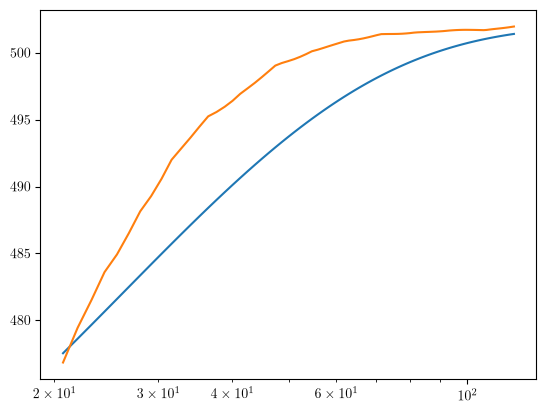

In [6]:
x_range = np.linspace(0.1, 120, 100)

mask = (x_range > 20)


plt.plot(x_range[mask], sigma_mod(x_range[mask], 355, *sig_pars))
plt.plot(x_range[mask], sigma_test(x_range[mask], 355))
plt.xscale('log')

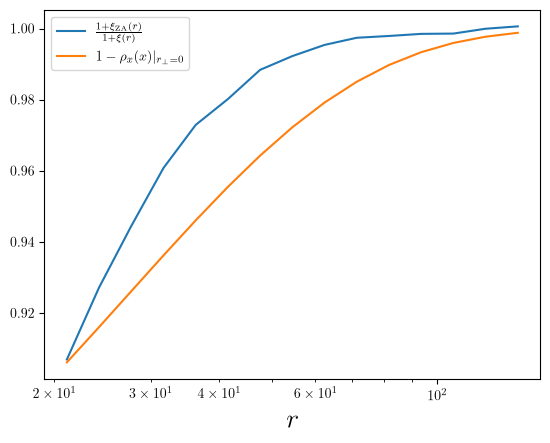

In [11]:
xizel = xizel_real(r_cens)
mask = (r_cens > 20)

par_test = [6.51412441e-01, 1.34127373e-01, 0, 0, 0, 0, 0, 0, 0]


ratio = (1+xizel)/(1+xihh) #_real(r_cens, par_test)

rho_x = sigma_mod(r_cens, 355, *sig_pars)**2/2/355**2

plt.plot(r_cens[mask], ratio[mask], label=r'$\frac{1+\xi_{\rm ZA}(r)}{1+\xi(r)}$')
plt.plot(r_cens[mask], rho_x[mask], label=r'$1-\rho_x(x)|_{r_\perp = 0}$' )
plt.xlabel(r'$r$')
plt.legend()
plt.xscale('log')